In [36]:
import numpy as np

import jax
import jax.numpy as jnp

import pandas as pd
import matplotlib.pyplot as plt

from flax import linen as nn

In [37]:
!head ../data/NGC6121-1.dat

/Users/bfarr/.local/share/uv/python/cpython-3.13.3-macos-aarch64-none/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


6045504229661220736 245.99162               -26.34434           18.438   
6045504981264184192 246.03035               -26.28057           18.769   
6045508902585952640 245.88761               -26.24297           19.072   
6045507180287440000 245.85343               -26.28453           18.495   
6045503473747038464 245.87124               -26.34628           17.163   
6045504229661219200 245.99971               -26.34076           17.441   
6045507459476748288 245.78997               -26.31094           18.499   
6045504160935345408 246.00232               -26.35289           18.593   
6045508077952053760 245.82044               -26.26234           17.033   
6045504229661219712 245.99428               -26.34374           17.094   


In [38]:
m4_df = pd.read_fwf('../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec', 'phot_g_mean_mag'])
m4_df

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


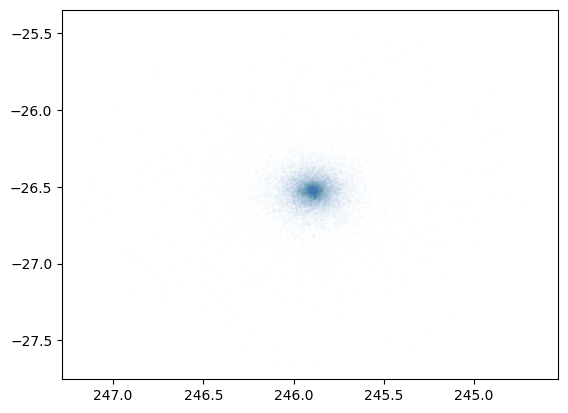

In [39]:
plt.scatter(m4_df.ra, m4_df.dec, s=0.0001)
plt.gca().invert_xaxis()


```sql
SELECT TOP 1000000 gaia_source.designation,gaia_source.source_id,gaia_source.ra,gaia_source.dec,gaia_source.parallax,gaia_source.parallax_error,gaia_source.parallax_over_error,gaia_source.pm,gaia_source.pmra,gaia_source.pmra_error,gaia_source.pmdec,gaia_source.pmdec_error,gaia_source.astrometric_n_good_obs_al,gaia_source.astrometric_chi2_al,gaia_source.visibility_periods_used,gaia_source.phot_g_mean_flux_over_error,gaia_source.phot_g_mean_mag,gaia_source.phot_bp_mean_flux_over_error,gaia_source.phot_bp_mean_mag,gaia_source.phot_rp_mean_flux_over_error,gaia_source.phot_rp_mean_mag,gaia_source.phot_bp_rp_excess_factor,gaia_source.bp_rp,gaia_source.radial_velocity,gaia_source.radial_velocity_error
FROM gaiadr3.gaia_source
WHERE 
CONTAINS(
	POINT('ICRS',gaiadr3.gaia_source.ra,gaiadr3.gaia_source.dec),
	BOX('ICRS',246,-26.5,3,3)
)=1
```

In [41]:
df = pd.read_csv('../data/m4_gaia_source.csv.gz')
df

,designation,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,...,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,radial_velocity,radial_velocity_error
0,Gaia DR3 6048466004733106048,6048466004733106048,244.500044,-26.152984,2.274643,1.125653,2.020732,8.490148,-7.892926,1.880442,...,110.199646,20.722200,4.511861,21.159956,17.483234,19.606243,1.661088,1.553713,NaN,NaN
1,Gaia DR3 6048666665606296064,6048666665606296064,244.500060,-25.906141,0.632528,0.769472,0.822029,2.582879,-0.097646,0.931963,...,178.075440,20.311983,10.519053,21.239437,20.069353,19.297583,1.380115,1.941855,NaN,NaN
2,Gaia DR3 6048358561832132864,6048358561832132864,244.500066,-26.918531,1.153917,0.907036,1.272184,7.455110,-5.327529,1.236975,...,152.003370,20.567377,7.892730,21.225716,16.701073,19.618095,1.404567,1.607620,NaN,NaN
3,Gaia DR3 6048842759265408128,6048842759265408128,244.500077,-25.216618,NaN,NaN,NaN,NaN,NaN,NaN,...,68.553120,20.875511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaia DR3 6048837635368203648,6048837635368203648,244.500085,-25.318745,0.405547,0.118409,3.424970,1.204035,-0.644142,0.158066,...,959.558700,17.849728,73.395320,18.590256,129.001560,16.973124,1.310396,1.617132,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494991,Gaia DR3 6045943823843054720,6045943823843054720,247.499972,-25.804701,0.400402,0.118593,3.376259,15.923029,-3.700880,0.151674,...,1137.301000,17.319313,77.892970,18.130360,165.200850,16.414494,1.312187,1.715866,NaN,NaN
494992,Gaia DR3 6045551057673424000,6045551057673424000,247.499973,-26.777081,-0.327392,0.258121,-1.268364,0.477848,-0.221657,0.309615,...,413.778380,18.781693,23.888437,19.568432,50.168346,17.908060,1.292541,1.660372,NaN,NaN
494993,Gaia DR3 6045942277654774400,6045942277654774400,247.499973,-25.873918,0.441350,0.286946,1.538096,9.224363,-2.628829,0.379642,...,360.979460,19.152878,19.316265,19.898535,48.930580,18.354532,1.243040,1.544002,NaN,NaN
494994,Gaia DR3 6045526662257584000,6045526662257584000,247.499979,-27.030542,0.081897,0.266952,0.306784,6.035001,-4.720757,0.312734,...,377.161040,18.966003,28.163189,19.675402,45.657240,18.220220,1.213934,1.455181,NaN,NaN


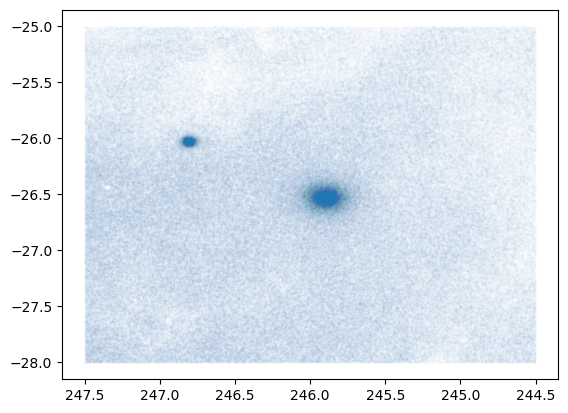

In [42]:
plt.scatter(df.ra, df.dec, s=0.0001)
plt.gca().invert_xaxis();

In [43]:
dq_sel = (df['parallax_over_error'] < 50.) & (df['pmra_error'] < 1.5) & (df['pmdec_error'] < 1.5)
df = df[dq_sel]
print(len(df))

346614


In [47]:
m4_sel = df['source_id'].isin(m4_df.source_id)

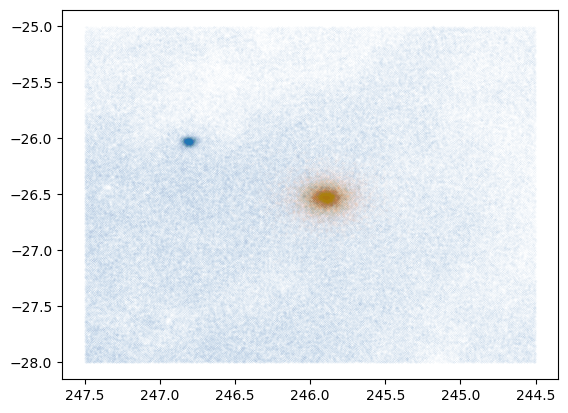

In [49]:
plt.scatter(df.ra[~m4_sel], df.dec[~m4_sel], s=0.0001)
plt.scatter(df.ra[m4_sel], df.dec[m4_sel], s=0.0001)
plt.gca().invert_xaxis();

In [50]:
df.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='str')

In [57]:
params = ['ra', 'dec']
X_raw = np.array(df[params])
X_raw.shape

(346614, 2)

In [58]:
np.count_nonzero(np.any(np.isnan(X_raw), axis=1))

np.int64(0)

In [55]:
X.mean(0)

array([246.13226001, -26.65565471])

In [56]:
from sklearn.preprocessing import StandardScaler

In [59]:
n_classes = 2
y = m4_sel.astype(int)

In [60]:
transfomer = StandardScaler()

X = jnp.array(transformer.fit_transform(X_raw))
y = jnp.array(y)

In [61]:
m = X.shape[0]
test_frac = 0.1
test_sel = np.random.choice([True, False], size=m, p=[test_frac, 1 - test_frac])
train_sel = ~test_sel
n_test = np.count_nonzero(test_sel)
n_train = m - n_test
print(n_test, n_train)

34554 312060


In [62]:
batch_size = 64
n_batches = n_train // batch_size
print(n_batches)

4875


In [ ]:
args = [a, b, c]
def func(a, b, c):
    ...

func(*args)

In [67]:
X_train = X[train_sel][:n_batches * batch_size].reshape((n_batches, batch_size, *X.shape[1:]))
y_train = y[train_sel][:n_batches * batch_size].reshape((n_batches, batch_size, *y.shape[1:]))
y_train.shape

(4875, 64)